<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/DataPreprocessing/lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

In [5]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print(df.shape)
print(df.dtypes)

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:
missing = df.isnull().sum()
pct = df.isnull().mean() * 100
print(pd.DataFrame({'count': missing, '%': pct.round(1)})[missing > 0])

          count     %
Age         177  19.9
Cabin       687  77.1
Embarked      2   0.2


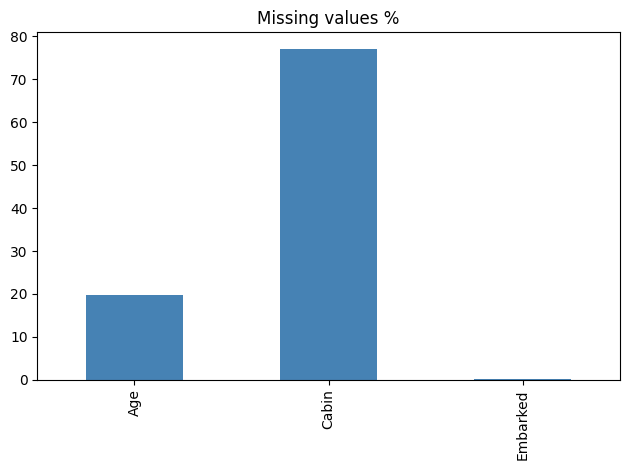

In [8]:
pct[pct > 0].plot(kind='bar', color='steelblue')
plt.title('Missing values %')
plt.tight_layout()
plt.show()

In [9]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [10]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


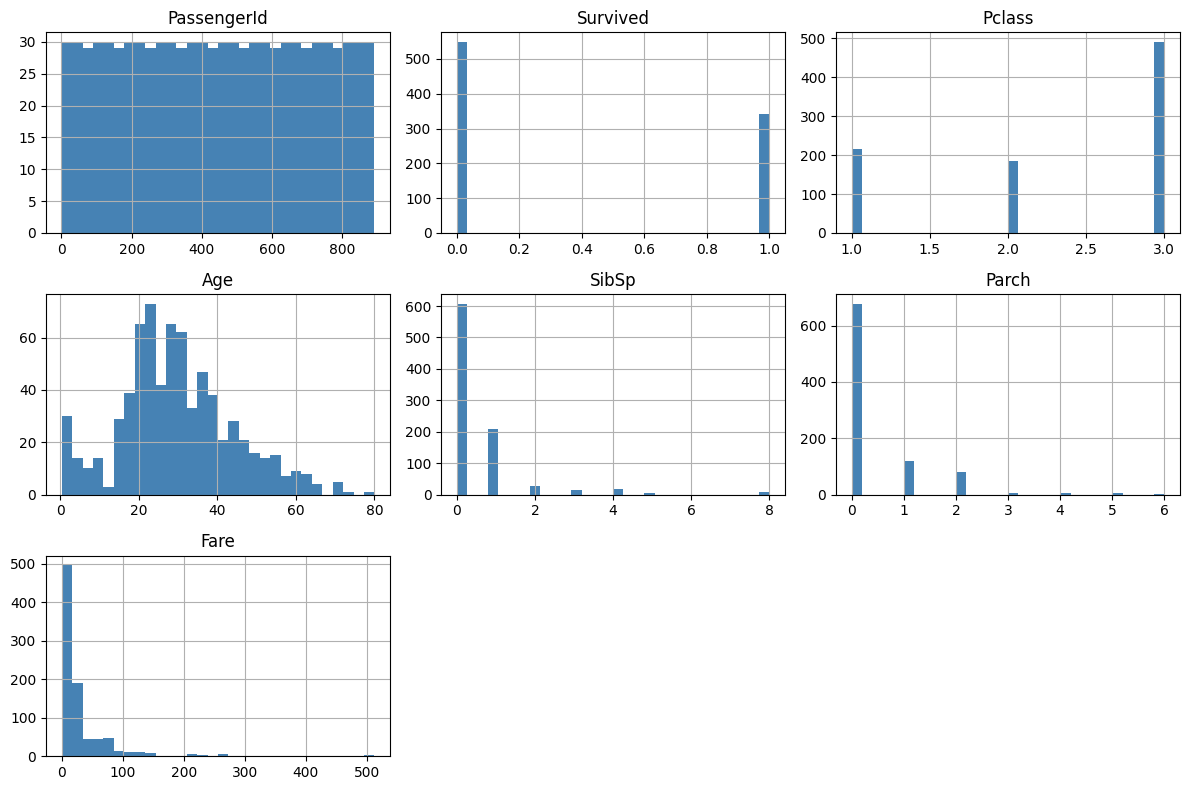

In [11]:
df.select_dtypes(include=np.number).hist(figsize=(12, 8), bins=30, color='steelblue')
plt.tight_layout()
plt.show()

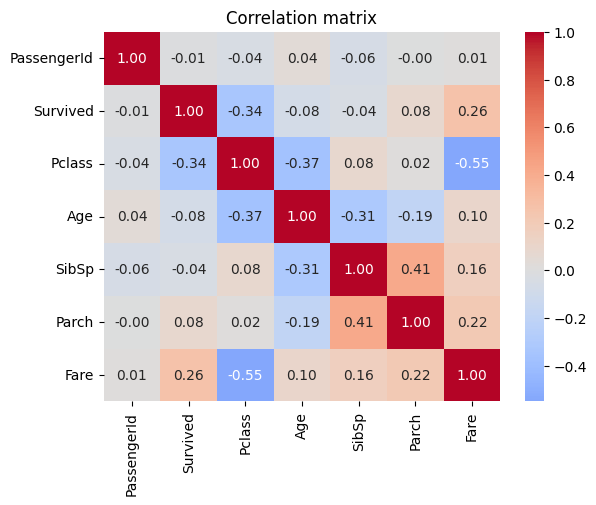

In [12]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [13]:
corr = df.select_dtypes(include=np.number).corr()
print(corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3))

Pclass        -0.338
Fare           0.257
Parch          0.082
Age           -0.077
SibSp         -0.035
PassengerId   -0.005
Name: Survived, dtype: float64


In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


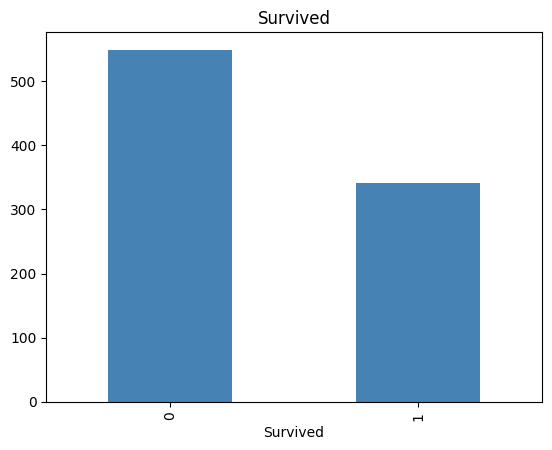

In [15]:
df['Survived'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Survived')
plt.show()

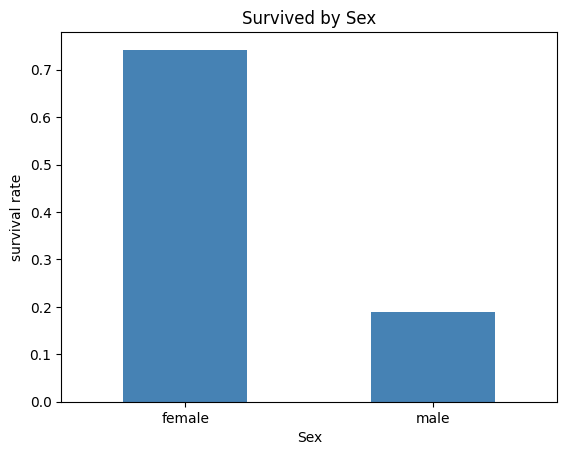

In [16]:
df.groupby('Sex')["Survived"].mean().plot(kind='bar', color='steelblue')
plt.title('Survived by Sex')
plt.ylabel("survival rate")
plt.xticks(rotation=0)
plt.show()

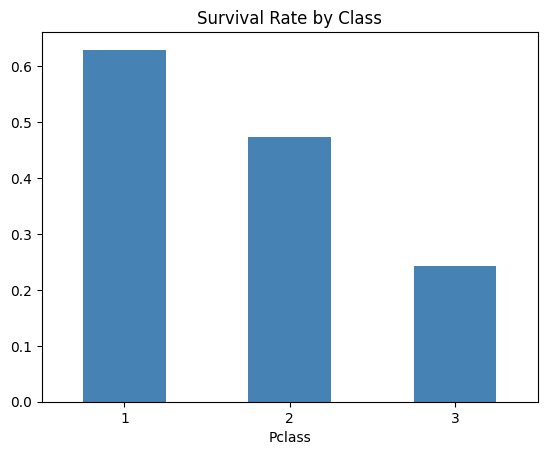

In [17]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Class')
plt.xticks(rotation=0)
plt.show()

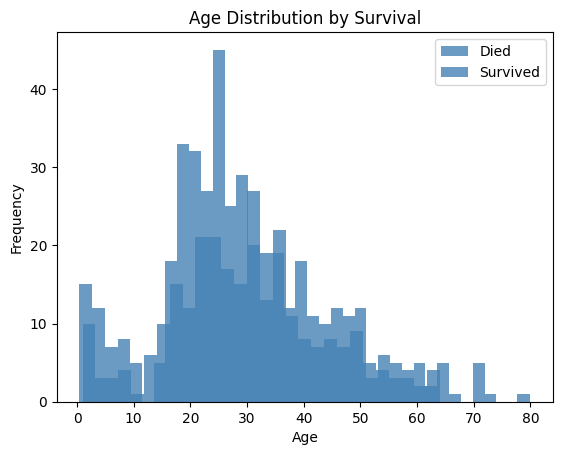

In [18]:
df.groupby("Survived")["Age"].plot(kind='hist', color='steelblue', alpha=0.8, bins=35, legend=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend(['Died','Survived'])
plt.show()

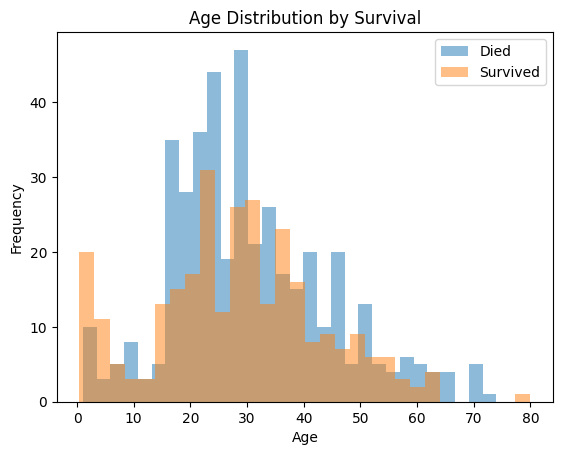

In [19]:
df.groupby('Survived')['Age'].plot(kind='hist', alpha=0.5, bins=30, legend=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend(['Died','Survived'])
plt.show()

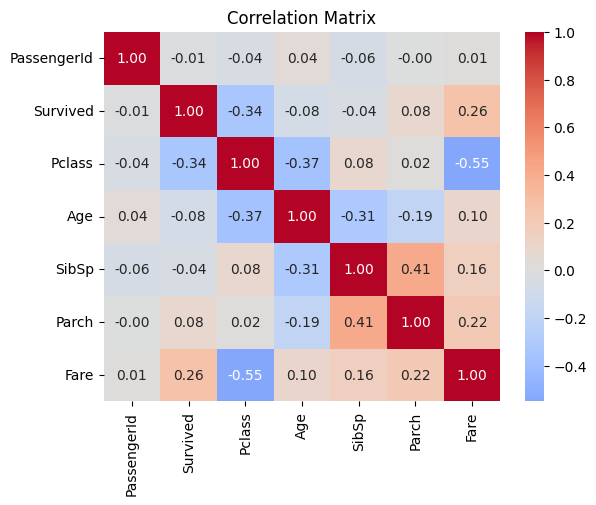

In [20]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [24]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [25]:
# df=df.drop(columns=['Cabin'])
# print(df.shape)

In [27]:
median_age=df['Age'].median()
print(f"median Age ;{median_age}")
df['Age']=df["Age"].fillna(median_age)
print(df['Age'].isnull().sum())


median Age ;28.0
0


In [29]:
mode_embarked=df['Embarked'].mode()[0]
print(f"mode Embarked ;{mode_embarked}")
df['Embarked']=df['Embarked'].fillna(mode_embarked)
print(df['Embarked'].isnull().sum())

mode Embarked ;S
0


In [32]:
print('before',len(df))
df=df.drop_duplicates()
print("after",len(df))

before 891
after 891


In [34]:
print("Age min/max:", df['Age'].min(), df['Age'].max())
print("Fare min/max:", df['Fare'].min(), df['Fare'].max())
print("Survived unique:", df['Survived'].unique())

Age min/max: 0.42 80.0
Fare min/max: 0.0 512.3292
Survived unique: [0 1]


In [36]:
print("Final shape:", df.shape)
print("Missing values left:")
print(df.isnull().sum())

Final shape: (891, 11)
Missing values left:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [52]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:", y.unique())

Features shape: (891, 10)
Target shape: (891,)
Target values: [0 1]


In [51]:
print(X.columns.tolist())

['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [42]:
print(y.value_counts())
print(y.value_counts(normalize=True).round(2))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # reproducibility
    stratify=y          # keeps same ratio in both splits
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 10)
X_test: (179, 10)
y_train: (712,)
y_test: (179,)


In [65]:
print("Original target ratio:")
print(y.value_counts(normalize=True).round(2))

print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTest target ratio:")
print(y_test.value_counts(normalize=True).round(2))

Original target ratio:
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Train target ratio:
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Test target ratio:
Survived
0    0.61
1    0.39
Name: proportion, dtype: float64


In [66]:
print(X.dtypes)

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [67]:
X_train = X_train.drop(columns=['Name', 'Ticket', 'PassengerId'])
X_test = X_test.drop(columns=['Name', 'Ticket', 'PassengerId'])
print(X_train.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [68]:
X_train['Sex']=X_train["Sex"].map({'male':0,'female':1})
X_test['Sex']=X_test["Sex"].map({'male':0,'female':1})
print(X_train['Sex'].value_counts())

Sex
0    459
1    253
Name: count, dtype: int64


In [69]:
X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Embarked'], drop_first=True)
print(X_train.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [71]:
print(X_train.shape)
X_train.head()

(712, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
692,3,0,28.0,0,0,56.4958,False,True
481,2,0,28.0,0,0,0.0000,False,True
527,1,0,28.0,0,0,221.7792,False,True
855,3,1,18.0,0,1,9.3500,False,True
801,2,1,31.0,1,1,26.2500,False,True


In [73]:
import scipy.stats as stats

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in numeric_cols:
    skew = X_train[col].skew()
    print(f"{col}: skew = {skew:.2f}")

Age: skew = 0.47
Fare: skew = 4.65
SibSp: skew = 3.82
Parch: skew = 2.84


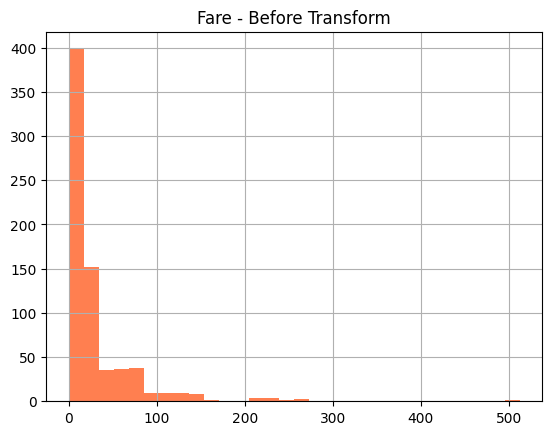

In [75]:
X_train['Fare'].hist(bins=30, color='coral')
plt.title('Fare - Before Transform')
plt.show()

In [78]:
X_train['Fare'] = np.log1p(X_train['Fare'])
X_test['Fare'] = np.log1p(X_test['Fare'])

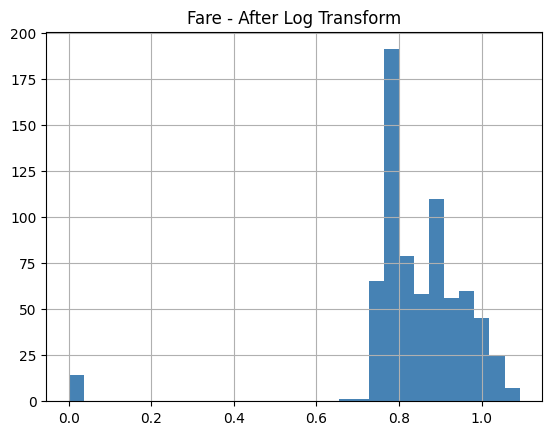

In [80]:
X_train['Fare'].hist(bins=30, color='steelblue')
plt.title('Fare - After Log Transform')
plt.show()

In [82]:
for col in numeric_cols:
    skew = X_train[col].skew()
    print(f"{col}: skew = {skew:.2f}")

Age: skew = 0.47
Fare: skew = -3.48
SibSp: skew = 3.82
Parch: skew = 2.84


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only — NEVER fit on test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # only transform, not fit

print("Train mean (should be ~0):", X_train_scaled.mean().round(3))
print("Train std (should be ~1):", X_train_scaled.std().round(3))

Train mean (should be ~0): 0.0
Train std (should be ~1): 1.0


In [86]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0.829568,-0.742427,-0.112078,-0.465084,-0.466183,0.834783,-0.289333,0.611978
1,-0.370945,-0.742427,-0.112078,-0.465084,-0.466183,-5.724249,-0.289333,0.611978
2,-1.571457,-0.742427,-0.112078,-0.465084,-0.466183,1.425898,-0.289333,0.611978
3,0.829568,1.346933,-0.879807,-0.465084,0.727782,-0.338754,-0.289333,0.611978
4,-0.370945,1.346933,0.118241,0.478335,0.727782,0.405757,-0.289333,0.611978


In [89]:
X_train_scaled.describe().round(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.57,-0.74,-2.23,-0.47,-0.47,-5.72,-0.29,-1.63
25%,-0.37,-0.74,-0.57,-0.47,-0.47,-0.48,-0.29,-1.63
50%,0.83,-0.74,-0.11,-0.47,-0.47,0.00,-0.29,0.61
75%,0.83,1.35,0.50,0.48,-0.47,0.51,-0.29,0.61
max,0.83,1.35,3.88,7.08,6.70,1.71,3.46,0.61


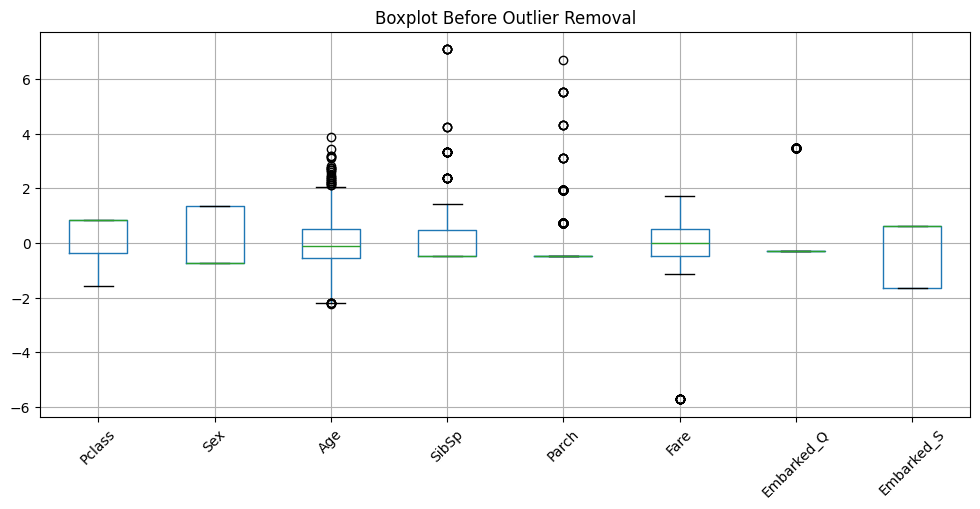

In [91]:
X_train_scaled.boxplot(figsize=(12,5))
plt.xticks(rotation=45)
plt.title('Boxplot Before Outlier Removal')
plt.show()

In [94]:
from scipy import stats

Q1 = X_train_scaled.quantile(0.25)
Q3 = X_train_scaled.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bounds:\n", lower.round(2))
print("\nUpper bounds:\n", upper.round(2))

Lower bounds:
 Pclass       -2.17
Sex          -3.88
Age          -2.18
SibSp        -1.88
Parch        -0.47
Fare         -1.97
Embarked_Q   -0.29
Embarked_S   -5.00
dtype: float64

Upper bounds:
 Pclass        2.63
Sex           4.48
Age           2.11
SibSp         1.89
Parch        -0.47
Fare          1.99
Embarked_Q   -0.29
Embarked_S    3.98
dtype: float64


In [97]:
# Reset index so everything lines up
X_train_scaled = X_train_scaled.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [99]:
mask = ((X_train_scaled >= lower) & (X_train_scaled <= upper)).all(axis=1)

X_train_clean = X_train_scaled[mask]
y_train_clean = y_train[mask]

print("Before:", X_train_scaled.shape)
print("After:", X_train_clean.shape)
print("Rows removed:", X_train_scaled.shape[0] - X_train_clean.shape[0])

Before: (712, 8)
After: (460, 8)
Rows removed: 252


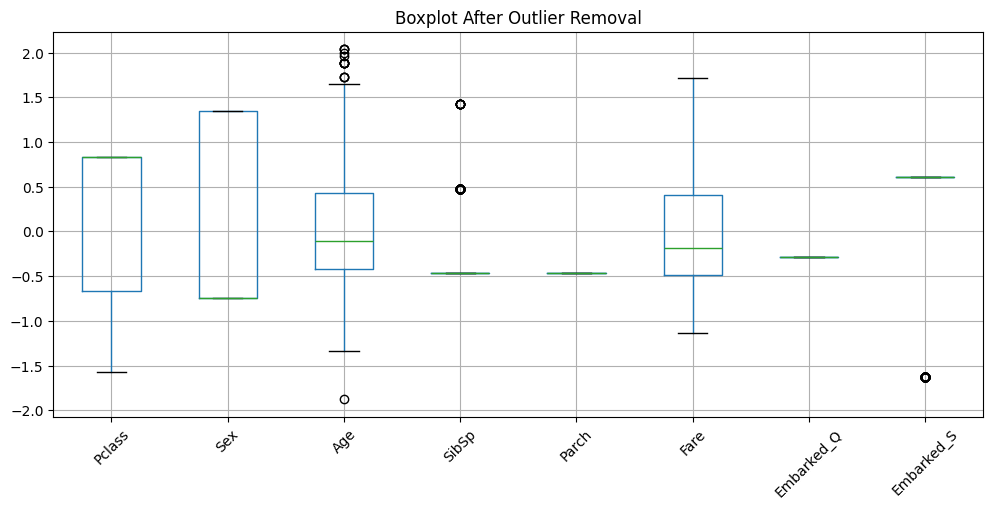

In [102]:
X_train_clean.boxplot(figsize=(12,5))
plt.xticks(rotation=45)
plt.title('Boxplot After Outlier Removal')
plt.show()

PCA

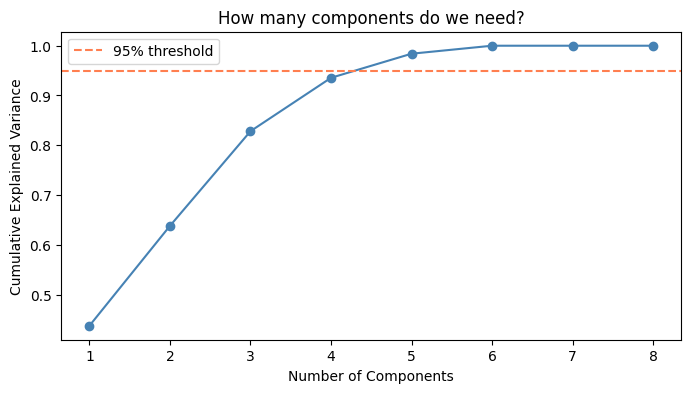

In [103]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_test = PCA()
pca_test.fit(X_train_clean)

cumulative_variance = pca_test.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='steelblue')
plt.axhline(y=0.95, color='coral', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('How many components do we need?')
plt.legend()
plt.show()

In [105]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_clean)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_clean.shape[1])
print("After PCA:", X_train_pca.shape[1])
print("Variance kept:", pca.explained_variance_ratio_.sum().round(3))

Original features: 8
After PCA: 5
Variance kept: 0.984


In [106]:
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i+1}: {var*100:.1f}% variance")

Component 1: 43.7% variance
Component 2: 20.1% variance
Component 3: 19.0% variance
Component 4: 10.7% variance
Component 5: 4.8% variance


Cross Validation


In [109]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

Logistic Regression: Mean = 0.798, Std = 0.043
Random Forest: Mean = 0.802, Std = 0.026


/tmp/ipykernel_1250/4245201022.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys())


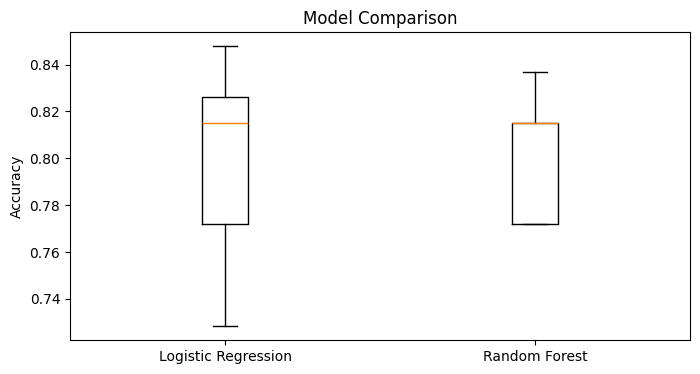

In [113]:
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_pca, y_train_clean, cv=5)
    results[name] = scores
    print(f"{name}: Mean = {scores.mean():.3f}, Std = {scores.std():.3f}")

# Plot
plt.figure(figsize=(8,4))
plt.boxplot(results.values(), labels=results.keys())
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

Evaluation

In [114]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_pca, y_train_clean)
y_pred = best_model.predict(X_test_pca)

In [115]:
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

              precision    recall  f1-score   support

        Died       0.75      0.83      0.78       110
    Survived       0.67      0.55      0.60        69

    accuracy                           0.72       179
   macro avg       0.71      0.69      0.69       179
weighted avg       0.72      0.72      0.71       179



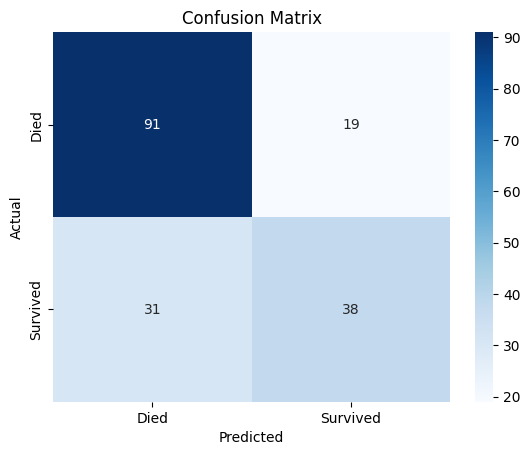

In [116]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [117]:
y_prob = best_model.predict_proba(X_test_pca)[:,1]
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.3f}")

AUC-ROC Score: 0.784


In [118]:
train_accuracy = best_model.score(X_train_pca, y_train_clean)
test_accuracy = best_model.score(X_test_pca, y_test)

print(f"Train accuracy: {train_accuracy:.3f}")
print(f"Test accuracy:  {test_accuracy:.3f}")
print(f"Gap:            {(train_accuracy - test_accuracy):.3f}")

Train accuracy: 0.976
Test accuracy:  0.721
Gap:            0.255


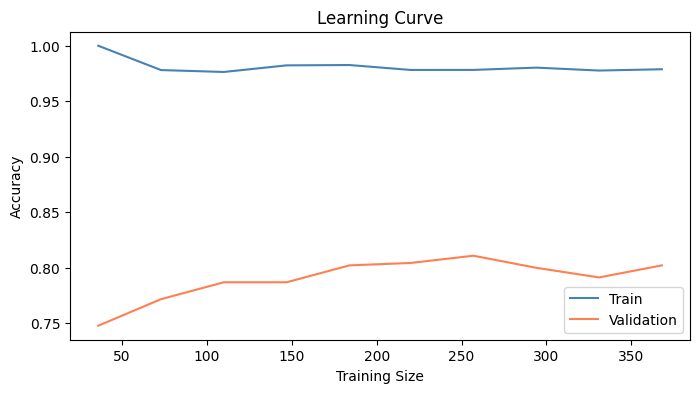

In [119]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_pca, y_train_clean, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8,4))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train', color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation', color='coral')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()